# 02: FAISS 類似度検索

抽出済みの embedding を FAISS インデックスに格納し、kNN 検索と類似度マップの可視化を行う。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium

from aef.config import EMBEDDINGS_DIR, INDEX_DIR
from aef.faiss_index import EmbeddingIndex
from aef.similarity import query_similar_regions, compute_similarity_map

## npz 読み込み

In [2]:
data = np.load(EMBEDDINGS_DIR / "hokkaido_farmland_2023.npz")
embeddings = data["embeddings"]
coords = data["coords"]
bbox = data["bbox"]
print(f"Embeddings: {embeddings.shape}, Coords: {coords.shape}")
print(f"BBox: {bbox}")

Embeddings: (3249, 64), Coords: (3249, 2)
BBox: [143.175  43.275 143.225  43.325]


## FAISS インデックス構築

In [3]:
index = EmbeddingIndex()
index.add(embeddings, coords)
index.metadata = {
    "region": "hokkaido_farmland",
    "year": 2023,
    "bbox": bbox.tolist(),
}
print(f"Index size: {index.ntotal} vectors")

# Save
index.save(INDEX_DIR / "default")
print("Index saved.")

Index size: 3249 vectors
Index saved.


## kNN 検索

In [4]:
# Load index to verify save/load
index = EmbeddingIndex.load(INDEX_DIR / "default")
print(f"Loaded index: {index.ntotal} vectors")

# Use center point as query
center_idx = len(embeddings) // 2
query_emb = embeddings[center_idx]
query_coord = coords[center_idx]
print(f"Query point: lon={query_coord[0]:.4f}, lat={query_coord[1]:.4f}")

# Search
df = query_similar_regions(index, query_emb, k=10)
df

Loaded index: 3249 vectors
Query point: lon=143.2000, lat=43.3000


,rank,similarity,index,lon,lat
0,1,0.998953,1624,143.200000,43.300000
1,2,0.997613,1568,143.200877,43.300877
2,3,0.995261,1567,143.200000,43.300877
3,4,0.994943,1569,143.201754,43.300877
4,5,0.994468,1623,143.199123,43.300000
5,6,0.994036,1684,143.202632,43.299123
6,7,0.992572,1513,143.202632,43.301754
7,8,0.992415,1570,143.202632,43.300877
8,9,0.992268,1685,143.203509,43.299123
9,10,0.990490,1741,143.202632,43.298246


## 類似度マップ可視化

Grid shape: 57 x 57


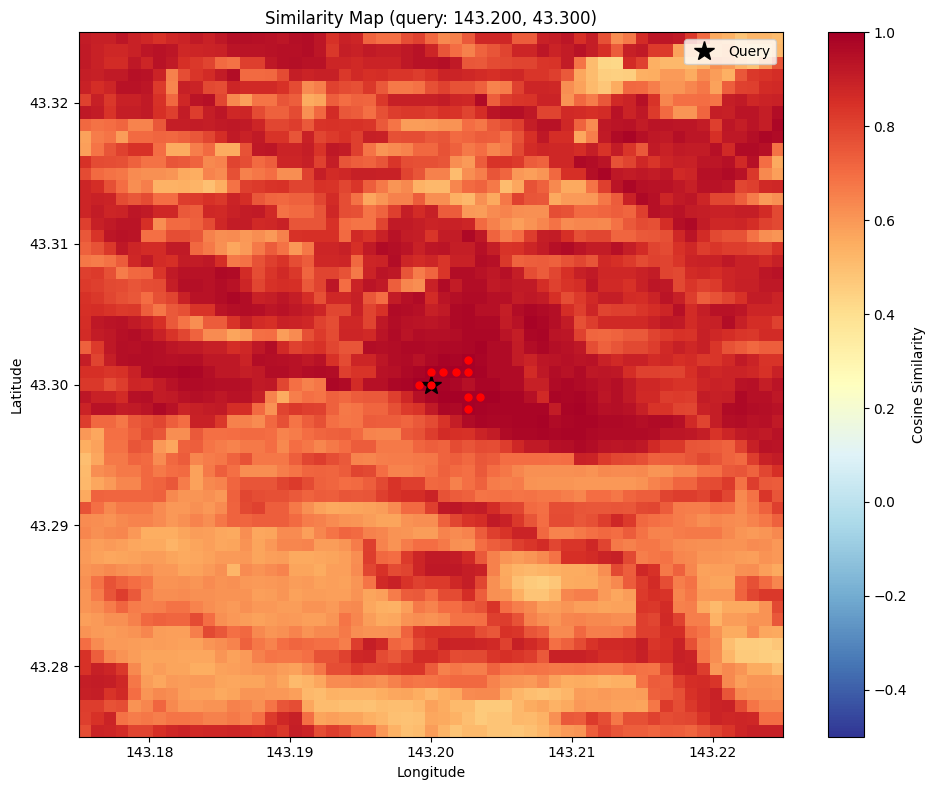

In [5]:
# Compute shape from bbox and coordinate count
west, south, east, north = bbox
unique_lons = len(np.unique(np.round(coords[:, 0], 6)))
unique_lats = len(np.unique(np.round(coords[:, 1], 6)))
h, w = unique_lats, unique_lons
print(f"Grid shape: {h} x {w}")

# Compute similarity map
sim_map = compute_similarity_map(embeddings, query_emb, (h, w))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(
    sim_map,
    extent=[west, east, south, north],
    origin="upper",
    cmap="RdYlBu_r",
    vmin=-0.5,
    vmax=1.0,
)
ax.plot(query_coord[0], query_coord[1], "k*", markersize=15, label="Query")

# Top 10 results
for _, row in df.iterrows():
    ax.plot(row["lon"], row["lat"], "ro", markersize=5)

ax.set_title(f"Similarity Map (query: {query_coord[0]:.3f}, {query_coord[1]:.3f})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.tight_layout()
plt.show()

## Folium マップ

In [6]:
center_lat = (south + north) / 2
center_lon = (west + east) / 2
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# Query point
folium.Marker(
    [query_coord[1], query_coord[0]],
    popup="Query",
    icon=folium.Icon(color="blue", icon="star"),
).add_to(m)

# Top 10 results
for _, row in df.iterrows():
    folium.CircleMarker(
        [row["lat"], row["lon"]],
        radius=6,
        color="red",
        fill=True,
        popup=f"Rank {row['rank']}: sim={row['similarity']:.3f}",
    ).add_to(m)

m